In [97]:
import os
#from pathlib import Path
#import re
import pandas as pd
import numpy as np
from PIL import Image
from skimage.color import rgb2gray
from skimage.draw import disk
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import math

In [57]:
def filename(path):
    """
    Return filename without extenstion
    """
    return os.path.splitext(os.path.basename(path))[0]

def draw_foci_with_radius(image_path, df, px_size_um, output_path):
    # Load image
    image = Image.open(image_path)
    image_name = filename(image_path)
    arr = np.array(image) # convert image to numpy matrix

    # Plot image
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(arr, cmap="gray")

    # Draw red circles
    for _, row in df.iterrows():

        x_px = row["x_um"] / px_size_um
        y_px = row["y_um"] / px_size_um
        r_px = row["sigma_um"] / px_size_um

        circle = Circle(
            (x_px, y_px),
            r_px,
            fill=False,
            edgecolor="red",
            linewidth=1
        )

        ax.add_patch(circle)

    # Match image coordinates
    ax.set_xlim(0, arr.shape[1])
    ax.set_ylim(arr.shape[0], 0)

    # Save imafe
    plt.savefig(
        f"{output_path}/{image_name}_sigma.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Do not display image
    plt.close(fig)

def foci_one_image(image_path, df, px_size_um, output_path):
    image = Image.open(image_path)  # load image
    image_name = filename(image_path) # get image name
    arr = np.array(image) # convert image to numpy matrix
    H, W = arr.shape # get number of pixels (512*512 for 16-bit image)

    # Iteration through the thunderSTORM dataframe
    for _, row in df.iterrows():
        x_px = row["x_um"] / px_size_um
        y_px = row["y_um"] / px_size_um
        r_px = row["sigma_um"] / px_size_um

        # Build circular mask (clipped automatically)
        rr, cc = disk((y_px, x_px), r_px, shape=(H, W))
        mask = np.zeros((H, W), dtype=bool)
        mask[rr, cc] = True
        disk((y_px, x_px), r_px, shape=(H, W))

        # Compute mean intensity
        if mask.sum() > 0:
            mean_intensity = arr[mask].mean()
        else:
            mean_intensity = np.nan

In [60]:
image_path = "/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/C2_MP_U2OS_fixed_siORC1_WT0.3_001.nd2_(series_01)_ROI_0234-0314.tif"
px_size_um = 0.058739
output_path = "/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/foci"
image = Image.open(image_path) # open image
arr = np.array(image) # convert image to matrix
arr = np.array(image, dtype=np.float32) # convert values to float
H, W = arr.shape # get number of pixels (512*512 for 16-bit image)
px_size_um = 0.058739

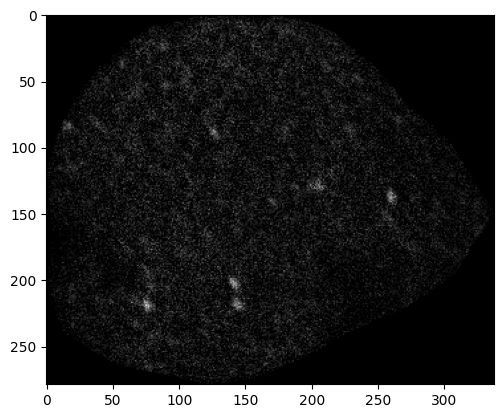

In [89]:
# Coordinates of nonzero pixels
rows, cols = np.nonzero(arr)

# Bounding box
rmin, rmax = rows.min(), rows.max()
cmin, cmax = cols.min(), cols.max()

# Crop
crop = arr[rmin:rmax+1, cmin:cmax+1]

# Show
plt.imshow(crop, cmap="gray")
plt.show()

In [108]:
for _, row in df.iterrows():
    x_px = int(row["x_um"] / px_size_um)
    c = int(row["y_um"] / px_size_um)
    r_px = math.ceil(row["sigma_um"] / px_size_um)

    # Build circular mask (clipped automatically)
    rr, cc = disk((y_px, x_px), r_px, shape=(H, W))
    mask = np.zeros((H, W), dtype=bool)
    mask[rr, cc] = True

    n_pixels_mask = np.sum(mask)

    # Compute mean intensity
    if n_pixels_mask > 1:
        mean_intensity = arr[mask].mean()
    else:
        mean_intensity = np.nan
    
    print(x_px, x_px, r_px, n_pixels_mask, mean_intensity)

154 154 1 1 nan
155 155 1 1 nan
160 160 2 9 1.3333334
161 161 2 9 0.5555556
159 159 1 1 nan
158 158 1 1 nan
161 161 1 1 nan
162 162 1 1 nan
161 161 2 9 0.5555556
162 162 1 1 nan
163 163 1 1 nan
164 164 1 1 nan
165 165 1 1 nan
164 164 1 1 nan
165 165 2 9 0.6666667
166 166 2 9 0.8888889
170 170 2 9 1.1111112
169 169 1 1 nan
172 172 3 25 1.44
172 172 1 1 nan
173 173 1 1 nan
173 173 1 1 nan
174 174 1 1 nan
178 178 2 9 1.4444444
178 178 1 1 nan
177 177 1 1 nan
180 180 1 1 nan
181 181 1 1 nan
181 181 1 1 nan
183 183 1 1 nan
182 182 1 1 nan
183 183 1 1 nan
186 186 1 1 nan
187 187 1 1 nan
188 188 1 1 nan
188 188 1 1 nan
187 187 2 9 1.4444444
189 189 1 1 nan
189 189 1 1 nan
191 191 2 9 1.7777778
191 191 1 1 nan
192 192 3 25 1.56
193 193 1 1 nan
194 194 1 1 nan
194 194 3 25 1.64
193 193 1 1 nan
195 195 1 1 nan
194 194 1 1 nan
195 195 1 1 nan
196 196 1 1 nan
198 198 1 1 nan
195 195 1 1 nan
196 196 1 1 nan
197 197 1 1 nan
200 200 1 1 nan
200 200 1 1 nan
203 203 2 9 2.5555556
202 202 2 9 1.2222222


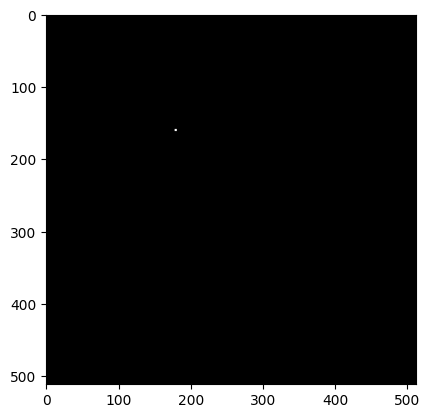

In [105]:
mask = np.zeros((512, 512), dtype=np.uint8)

rr, cc = disk((160, 179), 2, shape=mask.shape)

mask[rr, cc] = 1

plt.imshow(mask, cmap="gray")
plt.show()

In [82]:
img = np.zeros((10, 10))
rr, cc = disk((5, 4), 3, shape=img.shape)
img[rr, cc] = 1
        

In [83]:
img

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 1., 1., 1., 1., 0., 0., 0.],
       [0., 0., 1., 1., 1., 1., 1., 0., 0., 0.],
       [0., 0., 1., 1., 1., 1., 1., 0., 0., 0.],
       [0., 0., 1., 1., 1., 1., 1., 0., 0., 0.],
       [0., 0., 1., 1., 1., 1., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
mask = np.zeros((H, W), dtype=bool)
        mask[rr, cc] = True
        disk((y_px, x_px), r_px, shape=(H, W))

In [59]:
foci_one_image(image_path, df, px_size_um, output_path)

In [53]:
draw_foci_with_radius(image_path, df, px_size_um, output_path)

In [ ]:
image_path = "/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/C2_MP_U2OS_fixed_siORC1_WT0.3_001.nd2_(series_01).tif"
#image_path = "/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/foci/C2_MP_U2OS_fixed_siORC1_WT0.3_001.nd2_(series_01)_ROI_0234-0314_foci.png"




In [43]:
image = Image.open(image_path) # open image

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/foci/C2_MP_U2OS_fixed_siORC1_WT0.3_001.nd2_(series_01)_ROI_0234-0314_foci.tif'

In [56]:
image.shape()

AttributeError: 'TiffImageFile' object has no attribute 'shape'

In [29]:
filname = os.path.splitext(os.path.basename(image_path))[0]
filname

'C2_MP_U2OS_fixed_siORC1_WT0.3_001.nd2_(series_01)'

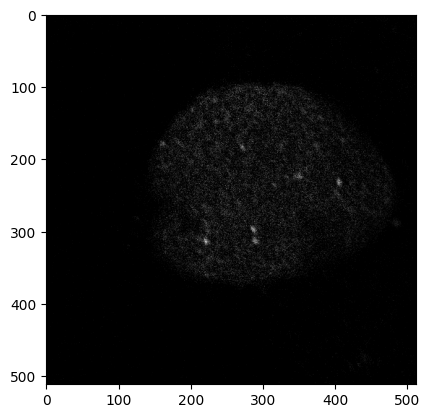

In [7]:
plt.imshow(image, cmap="gray")
plt.show()

In [18]:
f = "/mnt/c/users/elopatukhin/Desktop/Miscroscopy/160226_U2OS_fixed/MP_WT_0.3/foci/C2_MP_U2OS_fixed_siORC1_WT0.3_001.nd2_(series_01)_ROI_0234-0314_foci.csv"
df = pd.read_csv(f)
px_size_ts_x = 1
px_size_ts_y = 1
px_size_x = 58.7
px_size_y = 58.7

In [19]:
df["x_um"] = df["x [nm]"]/1000
df["y_um"] = df["y [nm]"]/1000
df["sigma_um"] = df["sigma [nm]"]/1000

In [21]:
df

,id,x [nm],y [nm],sigma [nm],intensity [photon],x_um,y_um,sigma_um
0,1.0,9098.278265,17753.074639,40.017841,16.523757,9.098278,17.753075,0.040018
1,2.0,9136.999106,12401.308820,47.103523,42.692367,9.136999,12.401309,0.047104
2,3.0,9428.050829,10551.778833,79.018673,110.932665,9.428051,10.551779,0.079019
3,4.0,9476.263273,10502.598320,70.661461,121.836552,9.476263,10.502598,0.070661
4,5.0,9380.491931,11574.509803,41.119091,16.520303,9.380492,11.574510,0.041119
...,...,...,...,...,...,...,...,...
584,585.0,26941.070723,13801.702262,46.988179,23.797248,26.941071,13.801702,0.046988
585,586.0,27011.685869,14549.041193,123.026256,0.821806,27.011686,14.549041,0.123026
586,587.0,27623.056270,15282.662310,40.721554,28.094449,27.623056,15.282662,0.040722
587,588.0,27788.812993,15022.673074,46.273279,29.746101,27.788813,15.022673,0.046273


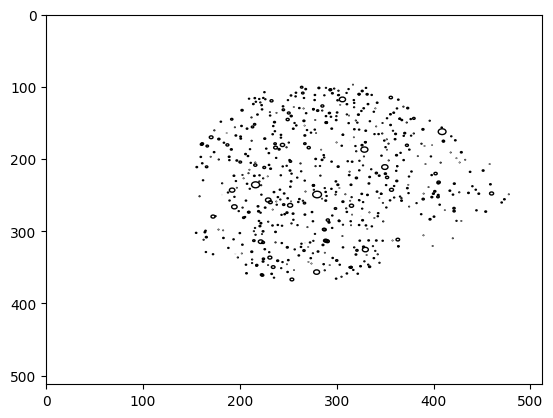

In [22]:
# Draw circles
for _, row in df.iterrows():
    x_px = row["x_um"] / px_size_um
    y_px = row["y_um"] / px_size_um
    r_px = row["sigma_um"] / px_size_um

    circle = Circle(
        (x_px, y_px),
        r_px,
        fill=False,
        linewidth=1
    )
    plt.gca().add_patch(circle)

plt.xlim(0, arr.shape[1])
plt.ylim(arr.shape[0], 0)  # important: image origin is top-left
plt.show()

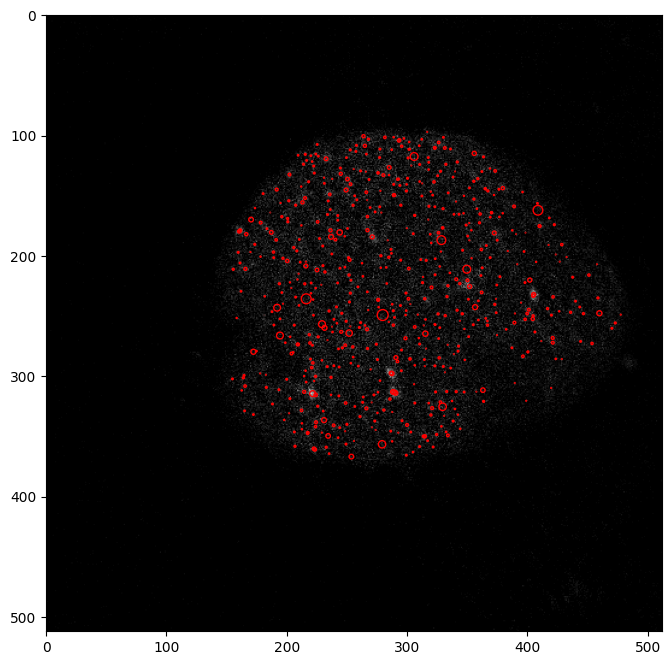

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Circle

# Load image
image = Image.open(image_path)
arr = np.array(image)

# Plot image
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(arr, cmap="gray")

# Draw red circles
for _, row in df.iterrows():

    x_px = row["x_um"] / px_size_um
    y_px = row["y_um"] / px_size_um
    r_px = row["sigma_um"] / px_size_um

    circle = Circle(
        (x_px, y_px),
        r_px,
        fill=False,
        edgecolor="red",
        linewidth=1
    )

    ax.add_patch(circle)

# Match image coordinates
ax.set_xlim(0, arr.shape[1])
ax.set_ylim(arr.shape[0], 0)

plt.show()